In [80]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import os

from pygments.util import split_path_re

path = kagglehub.dataset_download("camnugent/california-housing-prices")
print(os.listdir(f"{path}"))
df = pd.read_csv(f"{path}/housing.csv")

df = df.dropna()
df.head()

['housing.csv']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [81]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
df_encoded = ohe.fit_transform(df[['ocean_proximity']])
encoded_df = pd.DataFrame(
    df_encoded,
    columns=ohe.get_feature_names_out(['ocean_proximity']),
    index=df.index
)
df_reduced = df.drop('ocean_proximity', axis=1)
df = pd.concat([df_reduced, encoded_df], axis=1)

df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1.0,0.0,0.0,0.0


In [82]:
from sklearn.model_selection import train_test_split

X = df.drop('median_house_value', axis=1)
y = df[['median_house_value']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
532,-122.27,37.78,52.0,1408.0,280.0,718.0,265.0,2.6806,0.0,0.0,1.0,0.0
10557,-117.70,33.63,16.0,4428.0,745.0,1525.0,682.0,5.2325,0.0,0.0,0.0,0.0
1995,-119.77,36.72,43.0,1763.0,389.0,1623.0,390.0,1.4427,1.0,0.0,0.0,0.0
3340,-122.66,38.81,22.0,852.0,176.0,461.0,142.0,3.4375,1.0,0.0,0.0,0.0
10649,-117.79,33.55,39.0,5066.0,1292.0,1915.0,1117.0,3.8210,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
13193,-117.69,34.07,34.0,4055.0,739.0,2470.0,753.0,3.8586,1.0,0.0,0.0,0.0
3010,-118.99,35.27,32.0,444.0,102.0,242.0,87.0,1.1528,1.0,0.0,0.0,0.0
11421,-117.98,33.70,24.0,3451.0,504.0,1736.0,493.0,6.3749,0.0,0.0,0.0,0.0
6262,-117.96,34.04,33.0,1458.0,268.0,1115.0,257.0,4.7955,0.0,0.0,0.0,0.0


In [83]:
num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

In [84]:
scaler = StandardScaler()
X_train[num_cols] = pd.DataFrame(scaler.fit_transform(X_train[num_cols]))
X_test[num_cols] = pd.DataFrame(scaler.transform(X_test[num_cols]))

In [85]:
train_idx = X_train['housing_median_age'].isnull()
X_train = X_train[~train_idx]
y_train = y_train[~train_idx]

test_idx = X_test['housing_median_age'].isnull()
X_test = X_test[~test_idx]
y_test = y_test[~test_idx]

,median_house_value
532,207900.0
1995,47700.0
3340,83300.0
635,175000.0
564,286600.0
...,...
3477,344000.0
2721,61200.0
4613,253100.0
1857,105900.0


In [88]:
from sklearn import linear_model

lr = linear_model.LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
y_pred = lr.predict(X_test)

array([[220407.09869212],
       [132949.15110221],
       [147710.85331783],
       ...,
       [238538.53405479],
       [140904.06476307],
       [155155.11768083]])

In [94]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.27792042238811254
MAE: 76871.77315366227


In [95]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     251.0
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:31:36   Log-Likelihood:            -1.2753e+05
No. Observations:                9878   AIC:                         2.551e+05
Df Residuals:                    9865   BIC:                         2.552e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

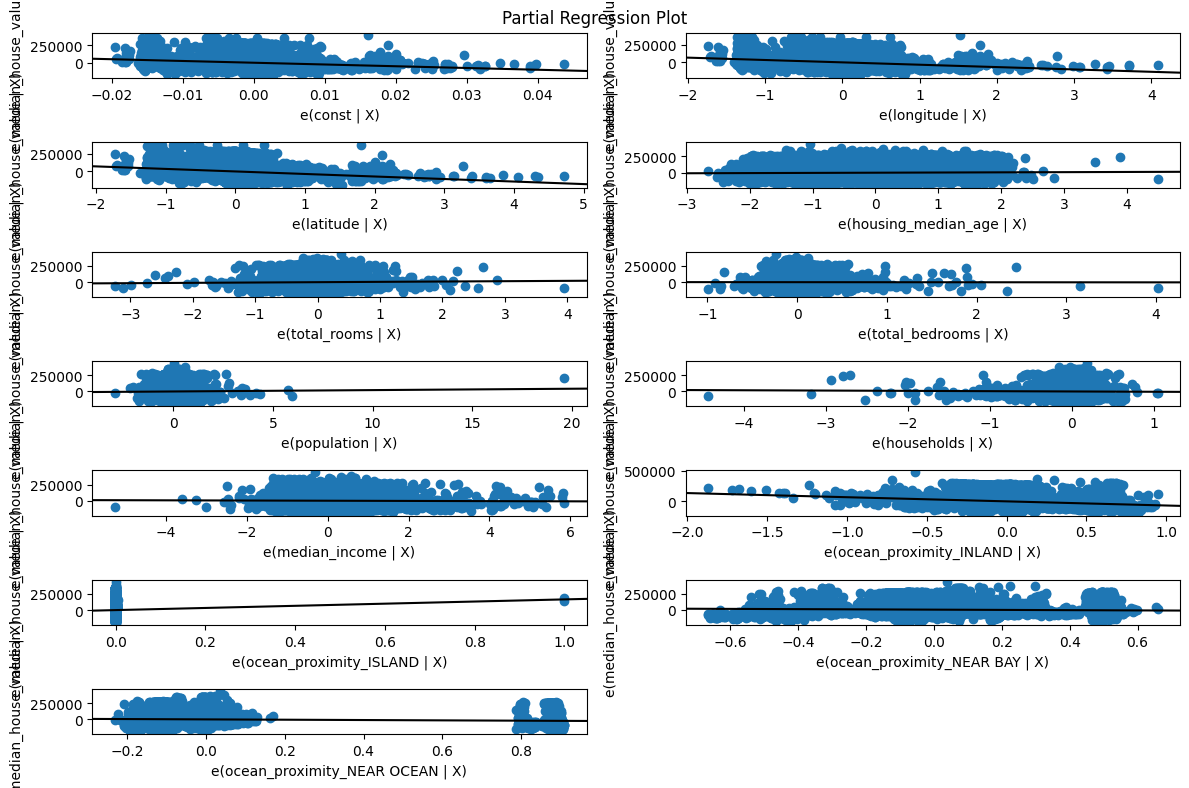

In [97]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assuming 'ols_model' is your fitted statsmodels object
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_partregress_grid(ols_model, fig=fig)
plt.show()

In [1]:
import XGBoost as xgb

ModuleNotFoundError: No module named 'XGBoost'